# Batch correction with ComBat

ComBat (Johnson, Li & Rabinovic, *Biostatistics* 2007) is an empirical-Bayes mean/variance adjustment of the expression matrix per batch. Unlike Harmony, ComBat returns a *corrected expression matrix* (`adata.obsm['X_combat']`) — useful when downstream tools need feature-level signal.

This is one of the **omicverse batch-correction zoo** tutorials. See [batch/index](../index.md) for the overview / decision tree, or [../t_single_batch](../t_single_batch.ipynb) for the side-by-side comparison of every backend on a real benchmark.

## Load a 2-batch demo from pbmc3k

We use the canonical 10x pbmc3k dataset and synthesise a 2-batch label by random assignment, then plant a gene-shift on `batch_B` so the uncorrected UMAP shows a visible batch effect. This keeps the notebook self-contained and fast (~2 min end-to-end) — for a real multi-donor benchmark with [scib-metrics] scoring, see [../t_single_batch](../t_single_batch.ipynb).

In [1]:
import omicverse as ov
import scanpy as sc
import numpy as np
import pandas as pd

# NeurIPS 2021 multimodal hematopoiesis dataset — 3 real donor batches
# (s1d3, s2d1, s3d7), pre-annotated `cell_type` and raw `layers['counts']`.
# Same datasets used by the overview notebook ../t_single_batch.ipynb.
adata1 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932005',
    filename='neurips2021_s1d3.h5ad',
)
adata2 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932008',
    filename='neurips2021_s2d1.h5ad',
)
adata3 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932011',
    filename='neurips2021_s3d7.h5ad',
)
adata = sc.concat([adata1, adata2, adata3], merge='same')
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs['batch'] = adata.obs['batch'].astype('category')

# Subsample to a quick-running ~6 000 cells × 3 batches so the CPU
# backends (harmony / combat / scanorama / cca) finish in well under a
# minute. Drop this line for a full-resolution run.
sc.pp.subsample(adata, n_obs=6000, random_state=0)
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


⚠️ File ./data/neurips2021_s1d3.h5ad already exists
 Loading data from ./data/neurips2021_s1d3.h5ad


✅ Successfully loaded: 5935 cells × 13953 genes
⚠️ File ./data/neurips2021_s2d1.h5ad already exists
 Loading data from ./data/neurips2021_s2d1.h5ad


✅ Successfully loaded: 10258 cells × 13953 genes
⚠️ File ./data/neurips2021_s3d7.h5ad already exists
 Loading data from ./data/neurips2021_s3d7.h5ad


✅ Successfully loaded: 11230 cells × 13953 genes


AnnData object with n_obs × n_vars = 6000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

## Preprocess + PCA + cluster

Same QC → HVG-pearson → log-norm → PCA pipeline shared across every backend in the zoo. A quick Leiden cluster gives a synthetic `celltype` label that scANVI / scPoli can use as a prototype anchor.

In [2]:
# Standard omicverse preprocess (QC → HVG-via-pearson → log-norm → PCA).
# QC thresholds are loose because the NeurIPS data is already filtered.
adata = ov.pp.qc(adata, tresh={'mito_perc': 0.2, 'nUMIs': 200,
                                 'detected_genes': 100})
ov.utils.store_layers(adata, layers='counts')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000,
                         batch_key=None)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features].copy()
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)

# Neighbours graph for the pre-correction UMAP.
sc.pp.neighbors(adata, use_rep='scaled|original|X_pca', n_neighbors=15)

# The NeurIPS adata already carries a real `cell_type` annotation —
# rename it to `celltype` for the wrapper's expected schema. No Leiden
# needed; the labels are pre-annotated by the dataset authors.
adata.obs['celltype'] = adata.obs['cell_type'].astype('category')
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 94                 │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 11                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 45 cells, 0 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.060
   ✓ scDblFinder completed: 171 doublets removed (2.9%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 36.6377s                                                │
│  Shape:    6,000 x 13,953 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚

/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_qc.py:1470: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['status'] = {}


...


✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 13,953 total (14.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 3.14 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_scale.py:737: UserWarning: zero-centering a sparse array/matrix densifies it.
  x, adata.var[str_mean_std[0]], adata.var[str_mean_std[1]] = scale_array(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_preprocess.py:1316: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__ <'1.10':



╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.142s                                                  │
│  Shape:    5,783 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 5783x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (5783, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (77.90s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 77.9007s                                                │
│  Shape:    5,783 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 5783x30)                               │
│           │ ✚ scaled|original|X_pca (array, 5783x30)               │
│        

AnnData object with n_obs × n_vars = 5783 × 2000
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'predicted_doublet', 'doublet_score', 'scdblfinder_doublet', 'scdblfinder_score', 'celltype'
    var: 'feature_types', 'gene_id', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'hig

## Uncorrected baseline

The planted batch effect is visible in the uncorrected UMAP:

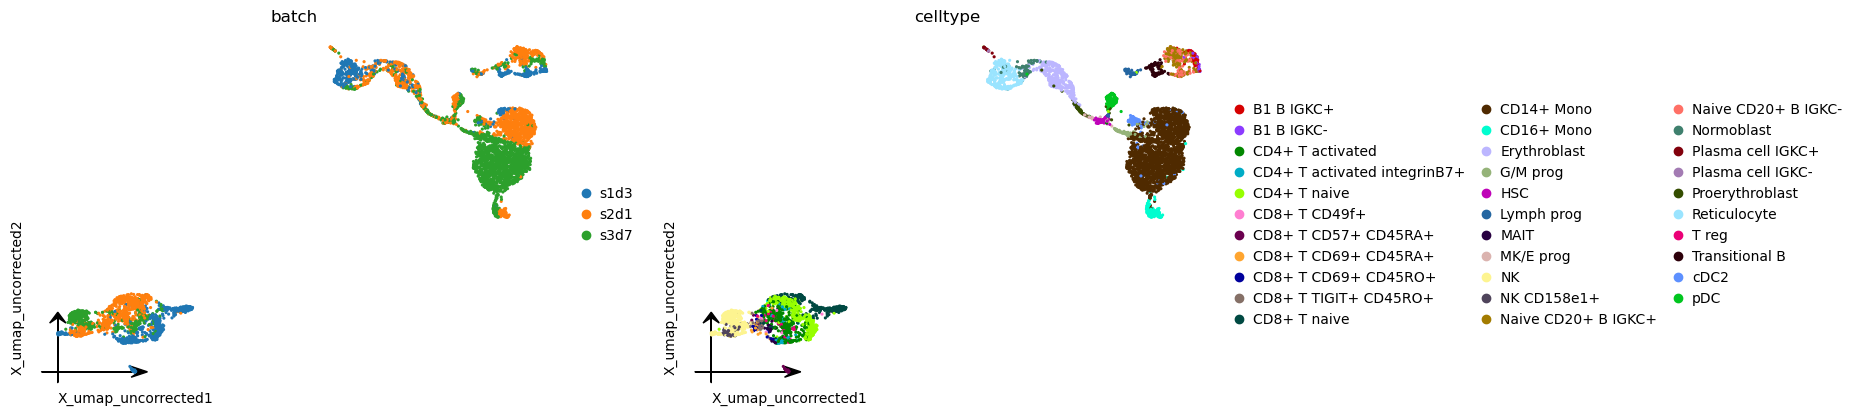

In [3]:
# Pre-correction UMAP shows the planted batch effect.
sc.tl.umap(adata, min_dist=0.3)
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()
ov.pl.embedding(adata, basis='X_umap_uncorrected',
                color=['batch', 'celltype'],
                frameon='small', wspace=0.5)

## Run `ov.single.batch_correction(methods='combat')`

For the scvi-tools family backends, the wrapper auto-routes `**kwargs` between the model's `__init__` (architecture) and `.train()` (optimisation) destinations. See the **Key parameters** section below.

In [4]:
ov.single.batch_correction(
    adata,
    batch_key='batch',
    methods='combat',
    n_pcs=30,
)

...Begin using combat to correct batch effect


computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (5783, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (73.91s)

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 77.3325s                                                │
│  Shape:    5,783 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ X_combat (array, 5783x30)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


## Corrected embedding

Every backend writes its corrected representation to a stable obsm key — for this one it is `adata.obsm['X_combat']`. We project via `ov.utils.mde` for a lightweight UMAP-style display.

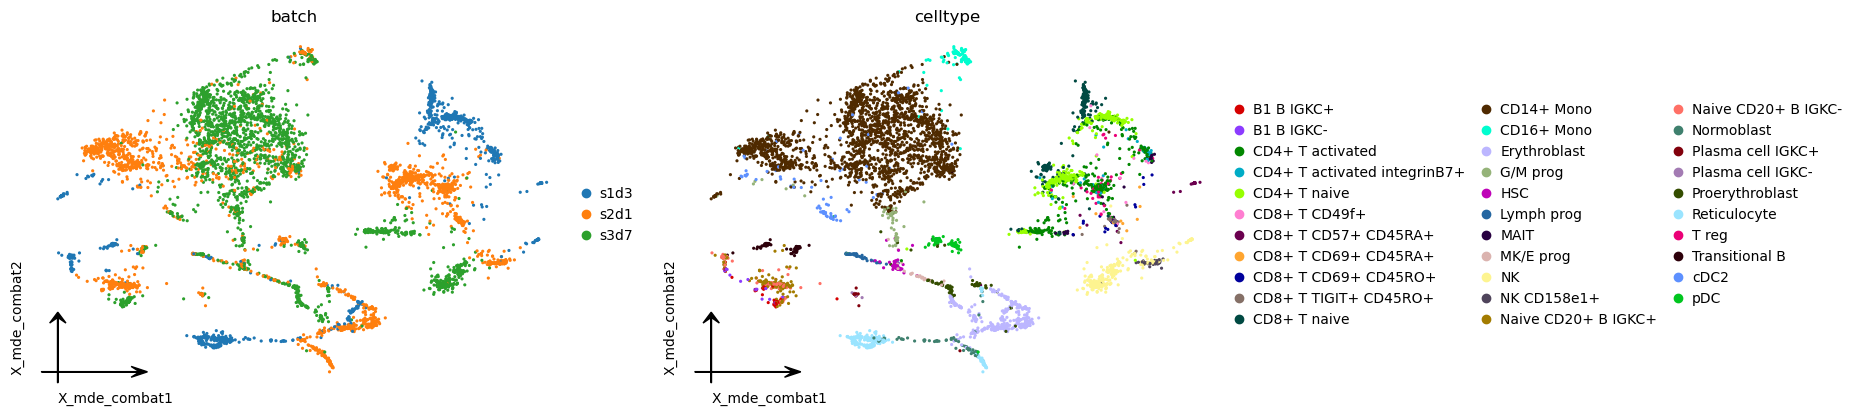

In [5]:
adata.obsm['X_mde_combat'] = ov.utils.mde(adata.obsm['X_combat'])
ov.pl.embedding(
    adata,
    basis='X_mde_combat',
    color=['batch', 'celltype'],
    frameon='small',
    wspace=0.5,
)

## Key parameters

- ComBat operates on the expression matrix directly; it doesn't take a `use_rep`.
- Only batch is modelled; biological covariates of interest should be regressed out separately.


## Related tutorials

- [t_batch_harmony](t_batch_harmony.ipynb) — embedding-only, faster for big datasets.
- [t_batch_scvi](t_batch_scvi.ipynb) — deep alternative.

For the full side-by-side comparison with scib-metrics scoring, see [../t_single_batch](../t_single_batch.ipynb).